In [1]:
import torch

In [2]:
from transformers import BertForSequenceClassification, BertTokenizer
model = BertForSequenceClassification.from_pretrained("../Models/bert_binary_model")
tokenizer = BertTokenizer.from_pretrained("../Models/bert_binary_model")

c:\Users\eddaoudi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from nltk.corpus import stopwords
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eddaoudi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
sw = stopwords.words('english')

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"[^a-zA-Z?.!,¿]+", " ", text) # replacing everything with space except (a-z, A-Z, ".", "?", "!", ",")

    text = re.sub(r"http\S+", "",text) #Removing URLs 
    #text = re.sub(r"http", "",text)
    
    html=re.compile(r'<.*?>') 
    
    text = html.sub(r'',text) #Removing html tags
    
    punctuations = '@#!?+&*[]-%.:/();$=><|{}^' + "'`" + '_'
    for p in punctuations:
        text = text.replace(p,'') #Removing punctuations
        
    text = [word.lower() for word in text.split() if word.lower() not in sw]
    
    text = " ".join(text) #removing stopwords
    
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text) #Removing emojis
    
    return text

In [8]:
def predict_label(text , threshold=0.6):
    # Tokenize the input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=465
    )

    with torch.no_grad():
            outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    max_prob, pred_label = torch.max(probs, dim=1)
        
    if max_prob.item() < threshold:
        return 1  # uncertain, better to pass
    return 1 if pred_label.item() == 1 else 0

text = "The red spots on the baby's face and lips that are dark red and almost purple are signs of hypoxia. Is this a sign of hypoxia?"
text = clean_text(text)
predicted_label = predict_label(text)

print("Predicted label:", predicted_label)


Predicted label: 1


In [17]:
from torch.utils.data import TensorDataset, DataLoader , SequentialSampler

In [ ]:
import pandas as pd

df_test = pd.read_csv('../Data/combined_dataset.csv')
df_test = df_test.head(500)
df_test['text'] = df_test['text'].apply(lambda x: clean_text(x))
test_texts = df_test['text'].values
label_actual = df_test['label'].values

predictions = []
for text in test_texts:
    predicted_label = predict_label(text)
    predictions.append(predicted_label)

predictions

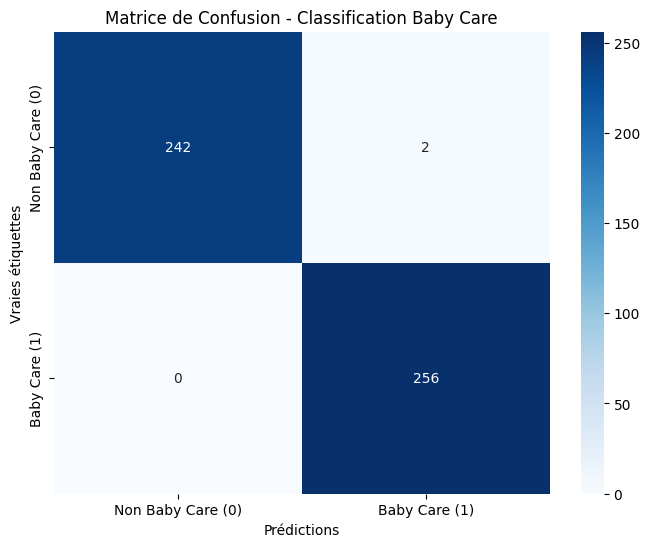

=== MÉTRIQUES DE PERFORMANCE ===
Accuracy: 0.9960
Nombre total d'échantillons: 500
Nombre de vrais positifs (Baby Care détectés): 256
Nombre de vrais négatifs (Non Baby Care détectés): 242
Nombre de faux positifs (Erreur Baby Care): 2
Nombre de faux négatifs (Erreur Non Baby Care): 0

=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===
               precision    recall  f1-score   support

Non Baby Care       1.00      0.99      1.00       244
    Baby Care       0.99      1.00      1.00       256

     accuracy                           1.00       500
    macro avg       1.00      1.00      1.00       500
 weighted avg       1.00      1.00      1.00       500


=== RÉPARTITION EN POURCENTAGES ===
Vrais positifs: 51.20%
Vrais négatifs: 48.40%
Faux positifs: 0.40%
Faux négatifs: 0.00%


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Ton code existant
df_test = pd.read_csv('../Data/combined_dataset.csv')
df_test = df_test.head(500)
df_test['text'] = df_test['text'].apply(lambda x: clean_text(x))
test_texts = df_test['text'].values
label_actual = df_test['label'].values

predictions = []
for text in test_texts:
    predicted_label = predict_label(text)
    predictions.append(predicted_label)

# Conversion en arrays numpy
y_true = np.array(label_actual)
y_pred = np.array(predictions)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Affichage de la matrice de confusion avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Baby Care (0)', 'Baby Care (1)'],
            yticklabels=['Non Baby Care (0)', 'Baby Care (1)'])
plt.title('Matrice de Confusion - Classification Baby Care')
plt.ylabel('Vraies étiquettes')
plt.xlabel('Prédictions')
plt.show()

# Affichage des métriques de performance
print("=== MÉTRIQUES DE PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Nombre total d'échantillons: {len(y_true)}")
print(f"Nombre de vrais positifs (Baby Care détectés): {cm[1,1]}")
print(f"Nombre de vrais négatifs (Non Baby Care détectés): {cm[0,0]}")
print(f"Nombre de faux positifs (Erreur Baby Care): {cm[0,1]}")
print(f"Nombre de faux négatifs (Erreur Non Baby Care): {cm[1,0]}")

print("\n=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===")
print(classification_report(y_true, y_pred, 
                          target_names=['Non Baby Care', 'Baby Care']))

# Affichage des pourcentages
print("\n=== RÉPARTITION EN POURCENTAGES ===")
total = len(y_true)
print(f"Vrais positifs: {cm[1,1]/total*100:.2f}%")
print(f"Vrais négatifs: {cm[0,0]/total*100:.2f}%")
print(f"Faux positifs: {cm[0,1]/total*100:.2f}%")
print(f"Faux négatifs: {cm[1,0]/total*100:.2f}%")